In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 100

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "Gender": np.random.choice(["Female", "Male"], n),
    "City": np.random.choice(["Bangalore", "Mumbai", "Delhi"], n),
    "Payment_Method": np.random.choice(["UPI", "Card", "Cash"], n),
    "Purchase_Amount": np.random.randint(500, 5000, n)
})

df["Purchased"] = (
    (df["Purchase_Amount"] > 2000) |
    (df["Age"] < 25)
).astype(int)

df.head()

,Age,Gender,City,Payment_Method,Purchase_Amount,Purchased
0,56,Female,Mumbai,UPI,3450,1
1,46,Male,Bangalore,Cash,4631,1
2,32,Male,Bangalore,UPI,4615,1
3,25,Male,Delhi,UPI,2868,1
4,38,Female,Mumbai,Card,4347,1


In [2]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for column in ["Gender", "City", "Payment_Method"]:
    encoder = LabelEncoder()
    df_encoded[column] = encoder.fit_transform(df_encoded[column])

df_encoded.head()

,Age,Gender,City,Payment_Method,Purchase_Amount,Purchased
0,56,0,2,2,3450,1
1,46,1,0,1,4631,1
2,32,1,0,2,4615,1
3,25,1,1,2,2868,1
4,38,0,2,0,4347,1


In [3]:
correlation = df_encoded.corr(numeric_only=True)

print(correlation["Purchased"].sort_values(ascending=False))

Purchased          1.000000
Purchase_Amount    0.676531
Payment_Method     0.034460
Gender             0.015134
City              -0.043331
Age               -0.158226
Name: Purchased, dtype: float64


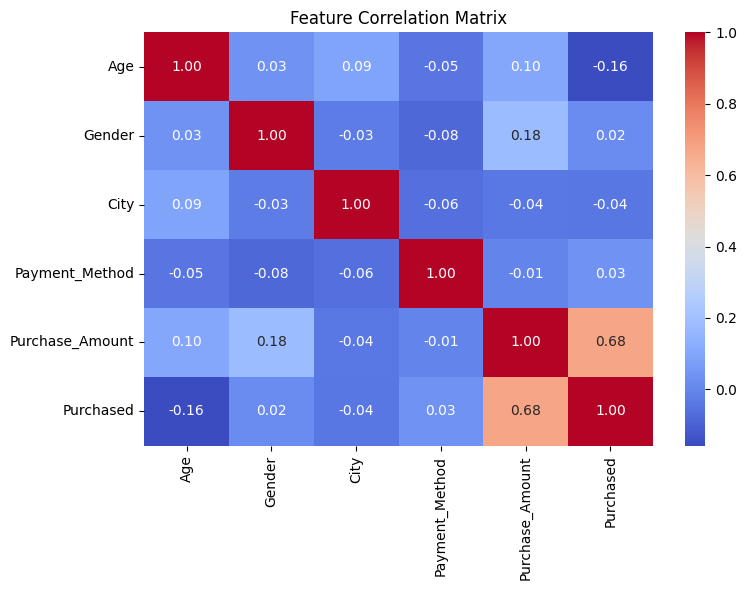

In [4]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [5]:
from sklearn.ensemble import RandomForestClassifier

X = df_encoded.drop("Purchased", axis=1)
y = df_encoded["Purchased"]

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
4,Purchase_Amount,0.819954
0,Age,0.143017
2,City,0.014694
1,Gender,0.011603
3,Payment_Method,0.010732


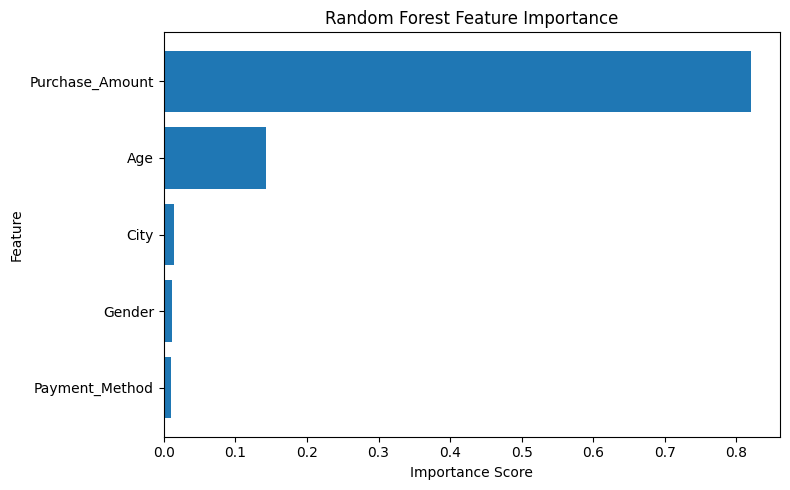

In [6]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [9]:
selected_features = ["Age", "Purchase_Amount"]

X_selected = df_encoded[selected_features]
y = df_encoded["Purchased"]

print("Selected Features:")
print(selected_features)

print("\nSelected Dataset Shape:", X_selected.shape)
X_selected.head()

Selected Features:
['Age', 'Purchase_Amount']

Selected Dataset Shape: (100, 2)


,Age,Purchase_Amount
0,56,3450
1,46,4631
2,32,4615
3,25,2868
4,38,4347


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# All features
X_full = df_encoded.drop("Purchased", axis=1)
y = df_encoded["Purchased"]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_full.fit(X_train_full, y_train_full)

pred_full = model_full.predict(X_test_full)

accuracy_full = accuracy_score(y_test_full, pred_full)

print("Accuracy BEFORE Feature Selection:", round(accuracy_full, 4))

Accuracy BEFORE Feature Selection: 1.0


In [11]:
# Selected features only
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_selected = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_selected.fit(X_train_selected, y_train_selected)

pred_selected = model_selected.predict(X_test_selected)

accuracy_selected = accuracy_score(
    y_test_selected,
    pred_selected
)

print("Accuracy AFTER Feature Selection:", round(accuracy_selected, 4))

Accuracy AFTER Feature Selection: 1.0


In [12]:
comparison = pd.DataFrame({
    "Model": ["Random Forest"],
    "Features Before Selection": [5],
    "Features After Selection": [2],
    "Accuracy Before": [accuracy_full],
    "Accuracy After": [accuracy_selected]
})

comparison

,Model,Features Before Selection,Features After Selection,Accuracy Before,Accuracy After
0,Random Forest,5,2,1.0,1.0


In [13]:
comparison.to_csv("day23_feature_selection_comparison.csv", index=False)

print("Feature selection comparison report saved successfully!")

Feature selection comparison report saved successfully!


In [14]:
importance.to_csv("day23_feature_importance.csv", index=False)

print("Feature importance report saved successfully!")

Feature importance report saved successfully!


In [15]:
print("Dataset Shape:", df.shape)

print("\nSelected Features:")
print(selected_features)

print("\nFeature Importance:")
print(importance)

print("\nPerformance Comparison:")
print(comparison)

print("\nDay 23 files:")
print("✓ day23_feature_selection.ipynb")
print("✓ day23_feature_importance.csv")
print("✓ day23_feature_selection_comparison.csv")

Dataset Shape: (100, 6)

Selected Features:
['Age', 'Purchase_Amount']

Feature Importance:
           Feature  Importance
4  Purchase_Amount    0.819954
0              Age    0.143017
2             City    0.014694
1           Gender    0.011603
3   Payment_Method    0.010732

Performance Comparison:
           Model  Features Before Selection  Features After Selection  \
0  Random Forest                          5                         2   

   Accuracy Before  Accuracy After  
0              1.0             1.0  

Day 23 files:
✓ day23_feature_selection.ipynb
✓ day23_feature_importance.csv
✓ day23_feature_selection_comparison.csv
